##### Copyright 2026 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Image Segmentation

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/tutorials/Image_Segmentation.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/tutorials/Image_Segmentation.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Ftutorials%2FImage_Segmentation.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/tutorials/Image_Segmentation.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

You can use Gemma 4 12B and larger models to analyze and segment the content of images.

Here are some examples demonstrating this capabilities.

This notebook will run on A100 GPU or higher.

## Install Python packages

Install the Hugging Face libraries required for running the Gemma model and making requests.

In [ ]:
# Install PyTorch & other libraries
!pip install torch accelerate matplotlib requests numpy pillow ipython

# Install the transformers library
!pip install "transformers>=5.10.1"

## Load Model

Use `transformers` library to load the pipeline

In [2]:
from transformers import pipeline

MODEL_ID = "google/gemma-4-12B-it" # @param ["google/gemma-4-12B-it","google/gemma-4-31B-it","google/gemma-4-26B-A4B-it"]

vqa_pipe = pipeline(
    task="image-text-to-text",
    model=MODEL_ID,
    dtype="auto",
    device_map="auto"
)
print(f"Default Image Token Budget: {vqa_pipe.image_processor.max_soft_tokens}")

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/23.9G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.5k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Default Image Token Budget: 280


## Helper function for plotting

Define a helper function to overlay the segmented polygon outlines on the image.

In [27]:
import json, re
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from IPython.display import display

def plot_segmentation(image, data, yx=True, below=0, ax=None):
    """
    Plots segmented polygons or bounding boxes on top of the image.

    Args:
        image: A PIL Image object.
        data: A list of segmentation/detection items. Each item is a dictionary:
              {"label": "object name", "outline": [[y1, x1], ...]} OR
              {"label": "object name", "box_2d": [ymin, xmin, ymax, xmax]}
        yx: If True, outline coordinates are in [y, x] order and need to be swapped to [x, y].
        below: Optional offset to display the text label below the polygon.
        ax: Optional matplotlib axes to plot on.
    """
    w, h = image.size

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)

    for item in data:
        label = item.get("label", "object")

        # 1. Handle Polygon Outlines
        if "outline" in item:
            outline = item["outline"]
            if not outline:
                continue
            pts = np.array(outline, dtype=np.float32)
            if yx:
                # Swap [y, x] to [x, y]
                pts = pts[:, ::-1]

            print(f"Plotting polygon outline for: '{label}' ({len(pts)} points)")
            # Scale coordinates from 0-1000 back to image dimensions
            pts[:, 0] = (pts[:, 0] / 1000.0) * w
            pts[:, 1] = (pts[:, 1] / 1000.0) * h

            poly = patches.Polygon(pts, facecolor="red", alpha=0.4, edgecolor="red", linewidth=2)
            ax.add_patch(poly)

            # Label at centroid
            cx, cy = np.mean(pts, axis=0)
            if below:
                cy = pts[:, 1].max() + below
            ax.text(cx, cy, label, color="white", fontsize=12, fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.3"),
                    ha="center", va="center")

        # 2. Handle Bounding Boxes
        elif "box_2d" in item:
            box = item["box_2d"]
            if not box or len(box) != 4:
                continue
            ymin, xmin, ymax, xmax = box
            print(f"Plotting bounding box for: '{label}' -> {box}")

            # Scale coordinates from 0-1000 back to image dimensions
            xmin = (xmin / 1000.0) * w
            ymin = (ymin / 1000.0) * h
            xmax = (xmax / 1000.0) * w
            ymax = (ymax / 1000.0) * h

            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     fill=False, edgecolor="red", linewidth=2)
            ax.add_patch(rect)

            # Label text above/inside box
            cx = (xmin + xmax) / 2
            cy = ymin - 10 if ymin > 20 else ymin + 15
            ax.text(cx, cy, label, color="white", fontsize=12, fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.3"),
                    ha="center", va="center")

    ax.axis("off")

def repair_and_load_json(json_str):
    """Attempts to fix truncated JSON strings by stripping trailing

    incomplete fragments and balancing open brackets/braces.
    """
    # 1. Clean up any obvious trailing trailing debris (like an isolated incomplete key/value)
    # This removes trailing commas, colons, or lone dangling characters at the very end
    json_str = json_str.strip()
    json_str = re.sub(r"[:,\s]+$", "", json_str)

    # 2. Track open brackets and braces
    stack = []
    fixed_str = ""

    # We iterate to find where the valid structural boundaries are
    for char in json_str:
        if char in "[{":
            stack.append(char)
        elif char in "]}":
            if not stack:
                break  # Malformed: closing without opening
            # Match pair
            if (char == "]" and stack[-1] == "[") or (
                char == "}" and stack[-1] == "{"
            ):
                stack.pop()
        fixed_str += char

    # 3. If it cut off mid-number or mid-array entry, we might have a dangling element
    # e.g., "[1, 2, 3" -> we want to keep "3" and close it -> "[1, 2, 3]"
    # But if it's "[1, 2, , " -> we need to clean the trailing comma
    fixed_str = re.sub(r",\s*$", "", fixed_str)

    # 4. Close the unclosed structures in reverse order
    # '[' needs ']', '{' needs '}'
    closure_map = {"[": "]", "{": "}"}
    while stack:
        fixed_str += closure_map[stack.pop()]

    # 5. Try parsing the repaired string
    return json.loads(fixed_str)

def display_result(output, image):
    # Locate JSON content and plot results
    start_idx = output.find("[")
    end_idx = output.rfind("]") + 1
    if start_idx != -1:
        if end_idx == 0:  # rfind returned -1, meaning no ']' exists at all
            json_str = output[start_idx:]
        else:
            json_str = output[start_idx:end_idx]

        data = repair_and_load_json(json_str)

        # Draw and show the plot
        plot_segmentation(image, data, yx=True)
        plt.show()
    else:
        display(image)
        print(f"Error: Failed to find valid JSON array format in model output.")

## Simple segmentation

Following code demonstrates how to perform image segmentation. It generates a test image containing a yellow square, sends it to a VQA (Visual Question Answering) pipeline with a prompt to segment the object, and then parses and visualizes the resulting coordinate data.

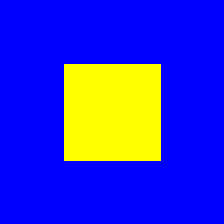

```json
[
  {"label": "yellow square", "outline": [[279, 283], [720, 283], [720, 716], [279, 716]]}
]
```<turn|>
Plotting polygon outline for: 'yellow square' (4 points)


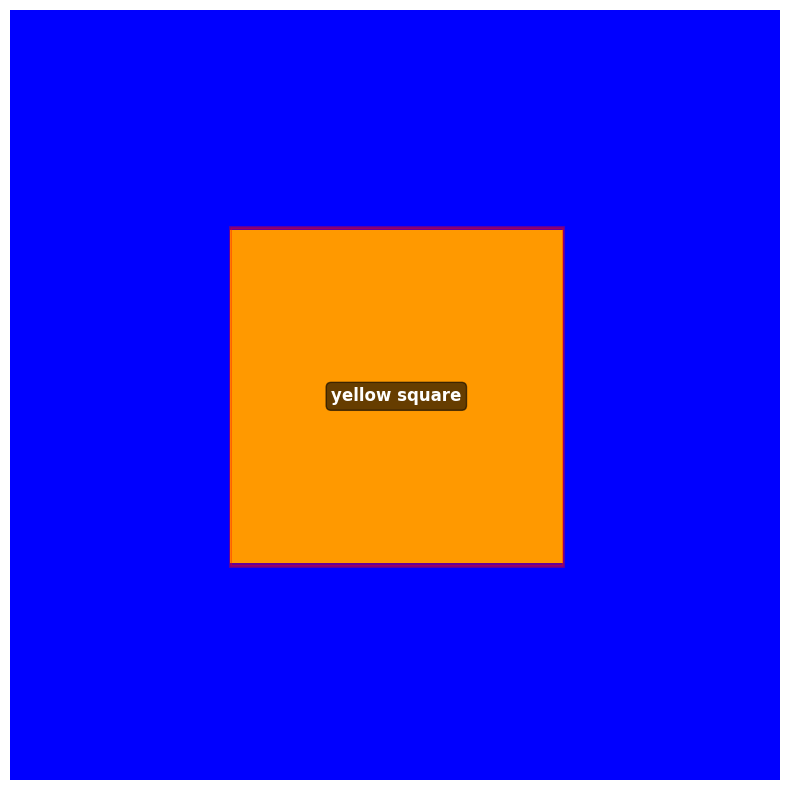

In [28]:
from PIL import Image, ImageDraw

test_image = Image.new("RGB", (224, 224), color="blue")
draw = ImageDraw.Draw(test_image)
draw.rectangle([64, 64, 160, 160], fill="yellow")

display(test_image)

system_prompt = 'when asked to segment objects in an image, return a JSON with the following format: [{"label": "...", "outline": [[y, x], ...]}]'

messages = [
    {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
    {"role": "user", "content": [{"type": "image", "image": test_image}, {"type": "text", "text": "segment yellow square"}]}
]

from transformers import GenerationConfig

config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)
vqa_pipe.image_processor.max_soft_tokens = 70

result = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
output = result[0]['generated_text']
print(output)

display_result(output, test_image)

## Segment and visualize objects

You can specify an input image via URL, choose a target object to segment, and configure the [token budget](https://ai.google.dev/gemma/docs/capabilities/vision#variable-resolution).

Following code will visualize the results.

```json
[
  {"label": "tower", "outline": [[364, 399], [376, 399], [383, 398], [394, 397], [406, 397], [418, 397], [433, 397], [444, 397], [456, 397], [467, 398], [481, 398], [494, 398], [507, 398], [524, 398], [539, 398], [550, 398], [562, 399], [573, 399], [586, 399], [599, 399], [611, 398], [623, 397], [634, 396], [645, 395], [657, 394], [668, 394], [683, 394], [696, 394], [709, 394], [722, 394], [728, 394], [728, 401], [727, 405], [724, 408], [716, 408], [706, 408], [694, 408], [683, 408], [667, 407], [650, 407], [632, 407], [618, 407], [604, 407], [587, 408], [573, 408], [558, 408], [543, 408], [527, 408], [513, 408], [500, 4
Plotting polygon outline for: 'tower' (49 points)


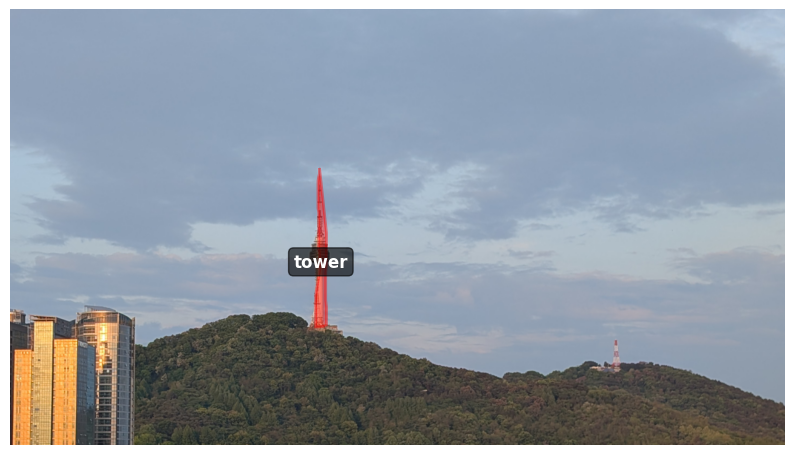

In [35]:
import requests
from PIL import Image
from transformers import GenerationConfig

img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/namsan.png" # @param {"type":"string"}
object_to_segment = "the tower" # @param ["the tower", "the building", "the mountain"] {"allow-input":true}
image_token_budget = 560 # @param ["70","140","280","560","1120"] {"type":"raw"}

config = GenerationConfig.from_pretrained(MODEL_ID)
config.max_new_tokens = 512
gen_kwargs = dict(generation_config=config)
vqa_pipe.image_processor.max_soft_tokens = image_token_budget

input_image = Image.open(requests.get(img_url, stream=True).raw)

system_prompt = 'when asked to trace objects in an image, return a JSON with the following format: [{"label": "...", "outline": [[y, x], ...]}]'

messages = [
    {
        "role": "system", "content": [{"type": "text", "text": system_prompt}]
    },
    {
        "role": "user", "content": [
            {"type": "image", "image": input_image},
            {"type": "text", "text": f"trace the polygon contour around {object_to_segment}"}
        ]
    }
]

result = vqa_pipe(messages, return_full_text=False, generate_kwargs=gen_kwargs)
output = result[0]['generated_text']
print(output)

display_result(output, input_image)

## Summary and next steps

In this guide, you learned how to use Gemma 4 models for the image segmentation task.

Check out the following documentation for further reading.

- [Prompt and system instructions](https://ai.google.dev/gemma/docs/core/prompt-formatting-gemma4)
- [Vision understanding](https://ai.google.dev/gemma/docs/capabilities/vision)
- [Function calling](https://ai.google.dev/gemma/docs/capabilities/text/function-calling-gemma4)
- [Run Gemma overview](https://ai.google.dev/gemma/docs/run)